Raw contestant-clue rows: 1,095,594

Dataset summary
----------------
Unique games: 6,308
Unique contestants: 11,883
Contestant-game records: 18,924
Unique clue records: 365,198
First air date: 1984-09-27
Last air date: 2019-07-26
Median clues per game: 59
Minimum clues per game: 1
Maximum clues per game: 61
Games with exactly 3 contestants: 6,308
Games with exactly 1 winner: 6,308

Missing values
contestant_intro    0.0
category            0.0
clue_text           0.0
correct_response    0.0
clue_value          0.0
Name: percent_missing, dtype: float64


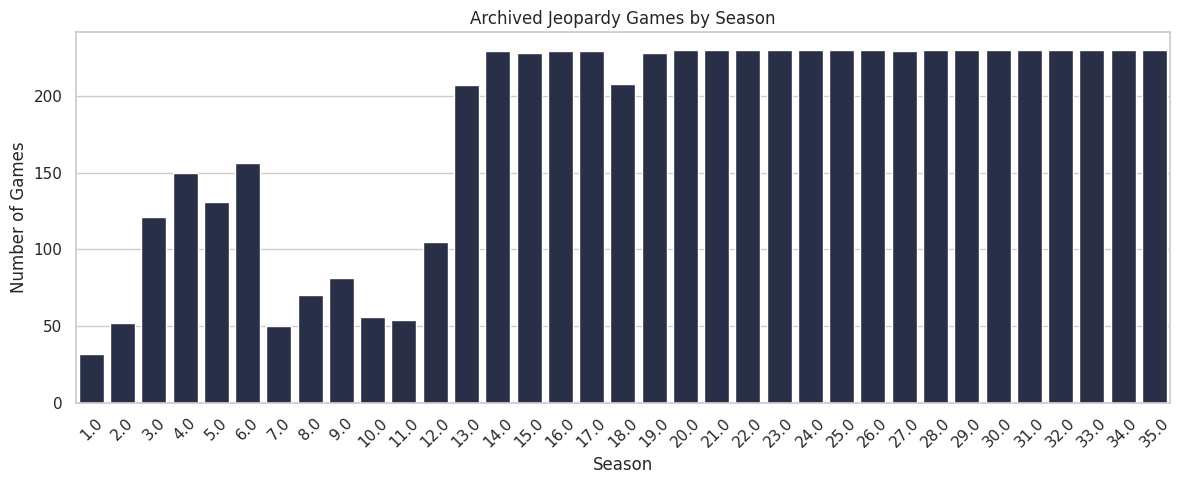

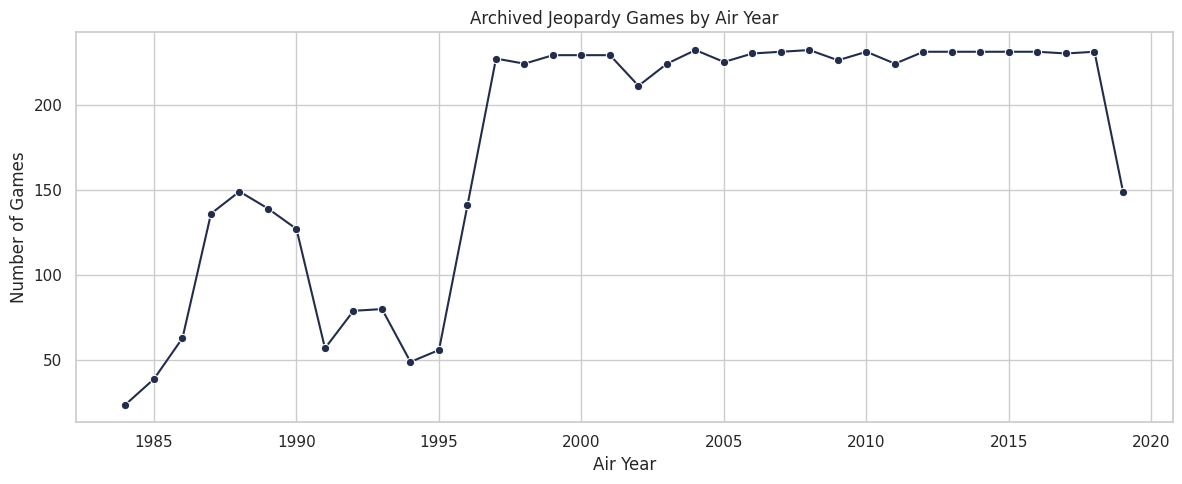

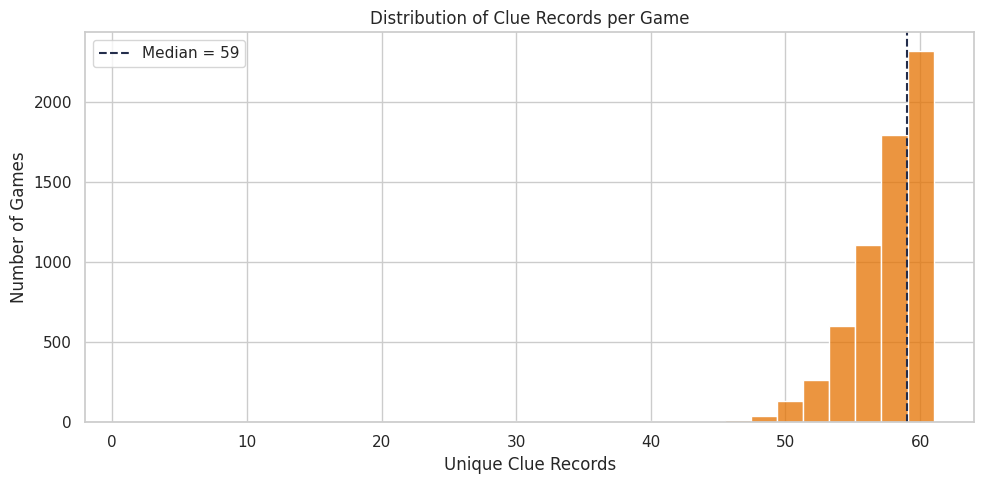

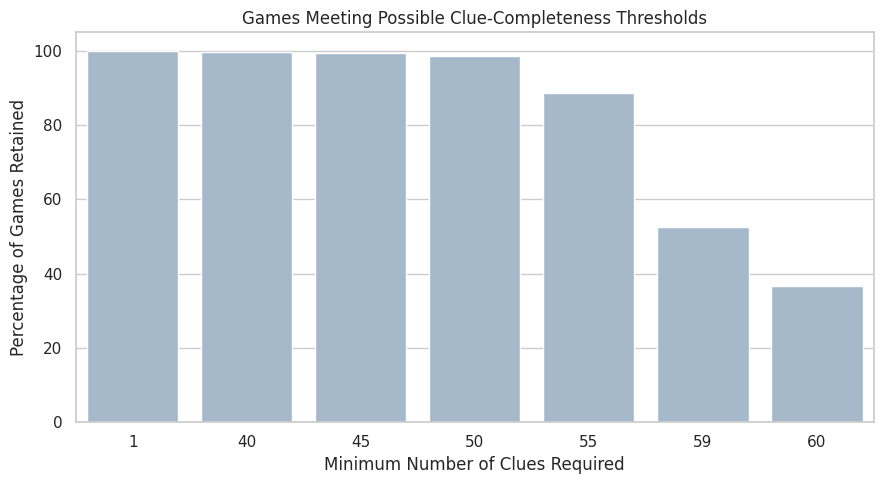

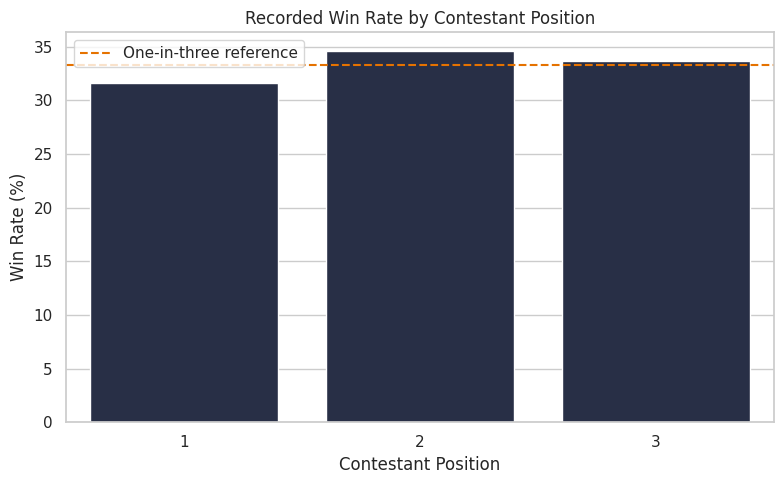

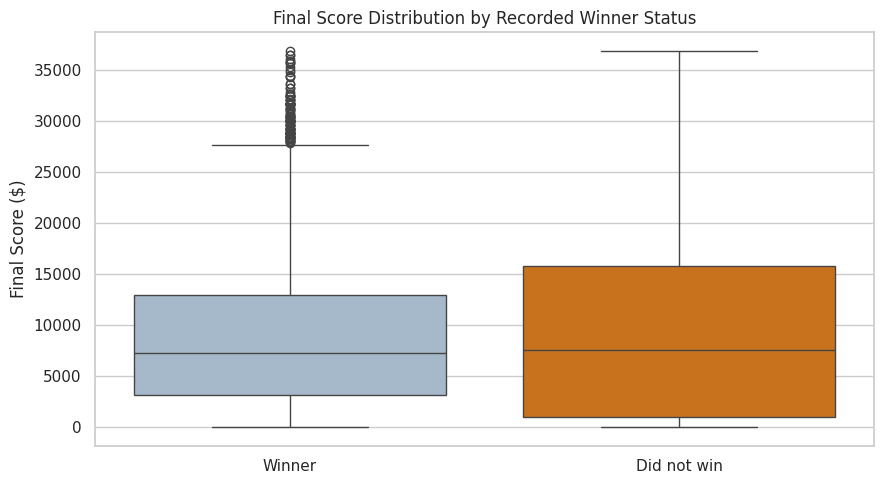

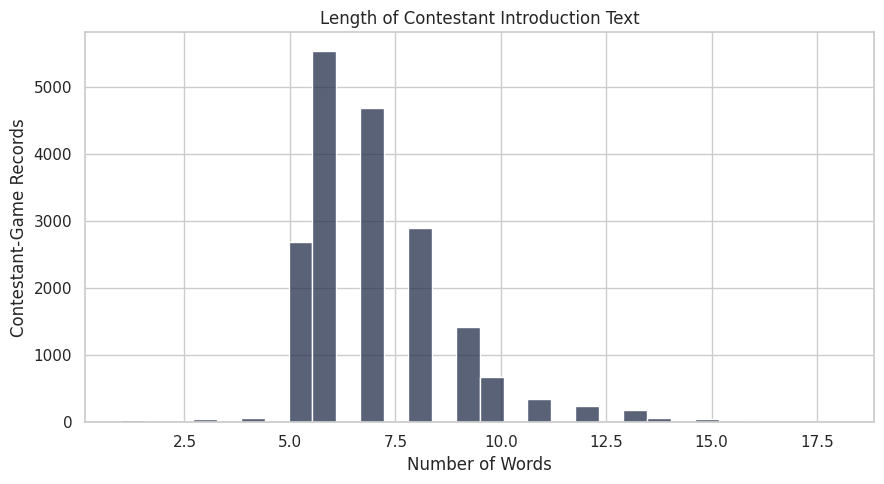

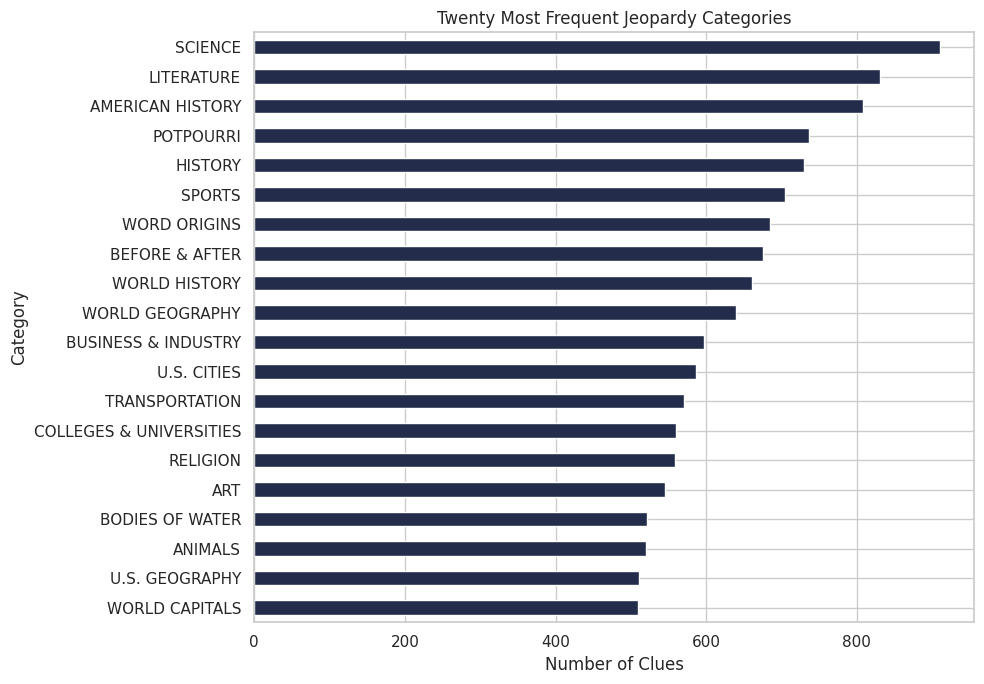

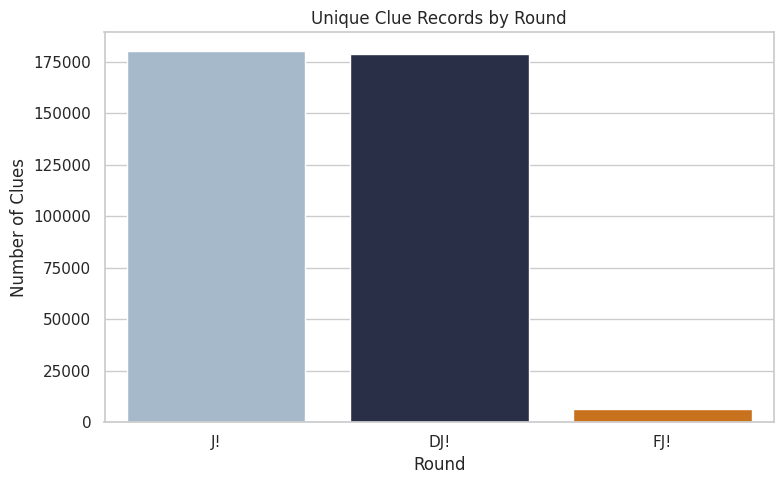

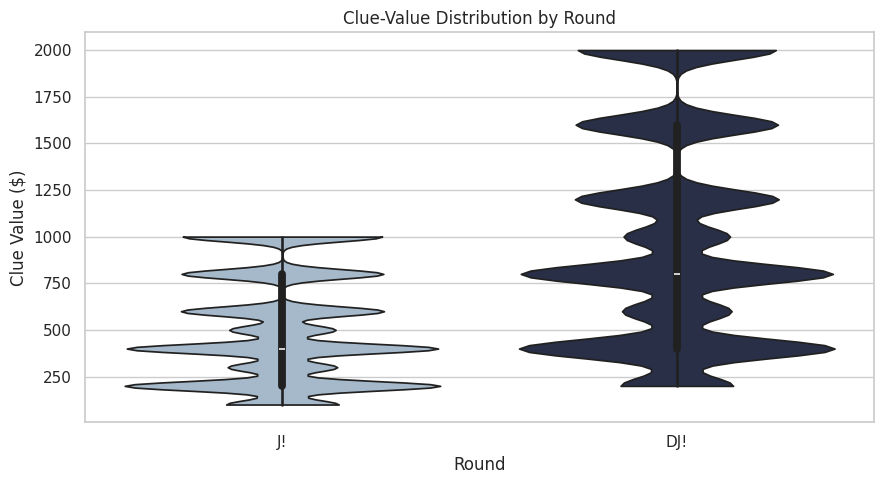

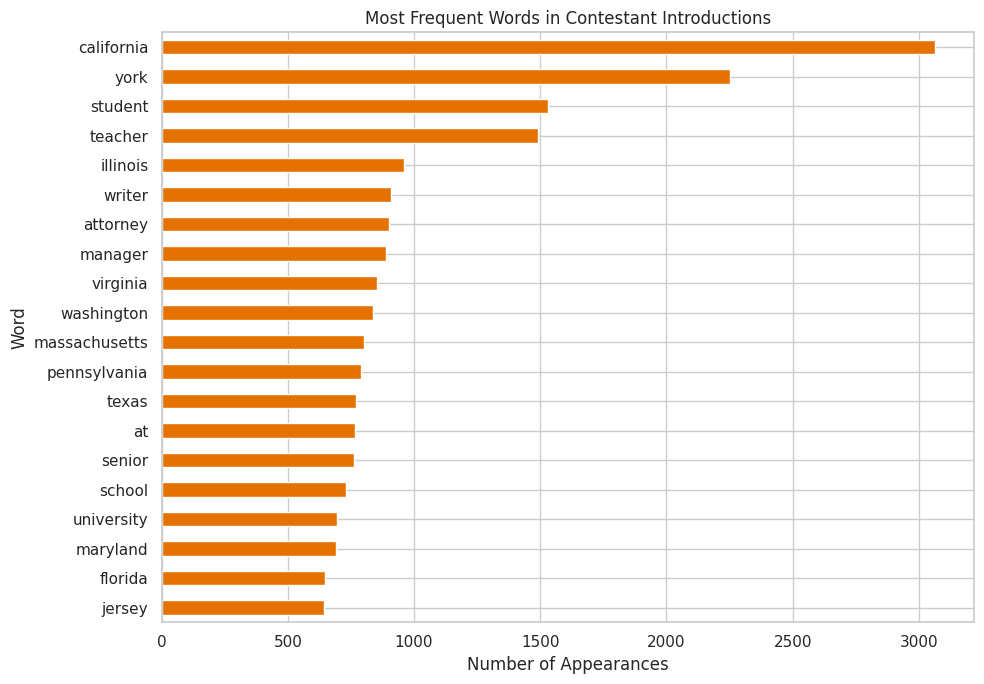

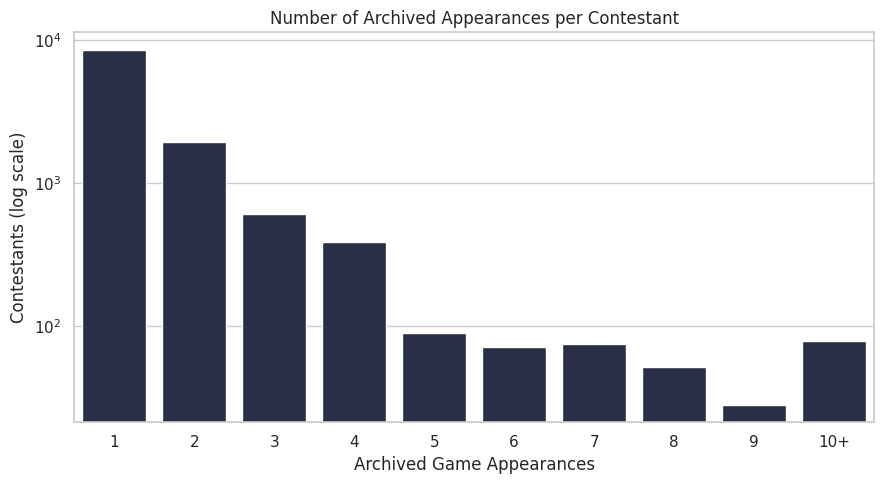


Plots saved in: /content/eda_plots


In [3]:
# If needed in Google Colab:
!pip install pandas matplotlib seaborn

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. SETTINGS
# ============================================================

DATA_PATH = Path("jeopardy_raw_contestant_clue_data.csv")
PLOT_DIRECTORY = Path("eda_plots")
PLOT_DIRECTORY.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")

NAVY = "#232D4B"
ORANGE = "#E57200"
LIGHT_BLUE = "#9FBAD0"
GRAY = "#6B7280"


# ============================================================
# 2. LOAD THE DATA
# ============================================================

# Loading selected columns uses less memory than reading all 39 columns.
columns_needed = [
    "game_id",
    "episode_num",
    "season_name",
    "air_date",
    "contestant_position",
    "contestant_id",
    "contestant_name",
    "contestant_intro",
    "contestant_games_played",
    "contestant_total_winnings",
    "contestant_final_score",
    "is_winner",
    "clue_source",
    "clue_source_record_id",
    "round",
    "clue_value",
    "daily_double_flag",
    "daily_double_value",
    "category",
    "clue_text",
    "correct_response",
]

raw = pd.read_csv(
    DATA_PATH,
    usecols=columns_needed,
    low_memory=False
)

raw["air_date"] = pd.to_datetime(raw["air_date"], errors="coerce")
raw["year"] = raw["air_date"].dt.year

print(f"Raw contestant-clue rows: {len(raw):,}")


# ============================================================
# 3. CREATE TABLES AT THE CORRECT LEVELS
# ============================================================

# One row per game
game_df = (
    raw[
        [
            "game_id",
            "episode_num",
            "season_name",
            "air_date",
            "year",
            "clue_source",
        ]
    ]
    .drop_duplicates(subset="game_id")
    .copy()
)

# One row per contestant per game
contestant_game_df = (
    raw[
        [
            "game_id",
            "season_name",
            "air_date",
            "year",
            "contestant_position",
            "contestant_id",
            "contestant_name",
            "contestant_intro",
            "contestant_games_played",
            "contestant_total_winnings",
            "contestant_final_score",
            "is_winner",
        ]
    ]
    .drop_duplicates(subset=["game_id", "contestant_id"])
    .copy()
)

# One row per clue
clue_df = (
    raw[
        [
            "game_id",
            "season_name",
            "air_date",
            "year",
            "clue_source",
            "clue_source_record_id",
            "round",
            "clue_value",
            "daily_double_flag",
            "daily_double_value",
            "category",
            "clue_text",
            "correct_response",
        ]
    ]
    .drop_duplicates(subset="clue_source_record_id")
    .copy()
)

# Extract the numeric season from labels such as "Season 35"
game_df["season_number"] = (
    game_df["season_name"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype("float")
)

clue_df["season_number"] = (
    clue_df["season_name"]
    .astype(str)
    .str.extract(r"(\d+)", expand=False)
    .astype("float")
)


# ============================================================
# 4. BASIC VALIDATION AND SUMMARY
# ============================================================

contestants_per_game = (
    contestant_game_df.groupby("game_id")["contestant_id"].nunique()
)

winners_per_game = (
    contestant_game_df.groupby("game_id")["is_winner"].sum()
)

clues_per_game = (
    clue_df.groupby("game_id")
    .size()
    .rename("clue_count")
    .reset_index()
)

game_summary = game_df.merge(clues_per_game, on="game_id", how="left")

print("\nDataset summary")
print("----------------")
print(f"Unique games: {game_df['game_id'].nunique():,}")
print(f"Unique contestants: {contestant_game_df['contestant_id'].nunique():,}")
print(f"Contestant-game records: {len(contestant_game_df):,}")
print(f"Unique clue records: {len(clue_df):,}")
print(f"First air date: {game_df['air_date'].min().date()}")
print(f"Last air date: {game_df['air_date'].max().date()}")
print(f"Median clues per game: {game_summary['clue_count'].median():.0f}")
print(f"Minimum clues per game: {game_summary['clue_count'].min():.0f}")
print(f"Maximum clues per game: {game_summary['clue_count'].max():.0f}")
print(f"Games with exactly 3 contestants: {(contestants_per_game == 3).sum():,}")
print(f"Games with exactly 1 winner: {(winners_per_game == 1).sum():,}")

print("\nMissing values")
print(
    raw[
        [
            "contestant_intro",
            "category",
            "clue_text",
            "correct_response",
            "clue_value",
        ]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("percent_missing")
)


# ============================================================
# HELPER FUNCTION FOR SAVING PLOTS
# ============================================================

def save_plot(filename):
    """Finish, save, display, and close the current plot."""
    plt.tight_layout()
    plt.savefig(
        PLOT_DIRECTORY / filename,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()
    plt.close()


# ============================================================
# PLOT 1: NUMBER OF GAMES BY SEASON
# ============================================================

season_counts = (
    game_df.dropna(subset=["season_number"])
    .groupby("season_number")["game_id"]
    .nunique()
    .reset_index(name="games")
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=season_counts,
    x="season_number",
    y="games",
    color=NAVY
)
plt.title("Archived Jeopardy Games by Season")
plt.xlabel("Season")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)
save_plot("01_games_by_season.png")


# ============================================================
# PLOT 2: NUMBER OF GAMES BY AIR YEAR
# ============================================================

year_counts = (
    game_df.dropna(subset=["year"])
    .groupby("year")["game_id"]
    .nunique()
    .reset_index(name="games")
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=year_counts,
    x="year",
    y="games",
    marker="o",
    color=NAVY
)
plt.title("Archived Jeopardy Games by Air Year")
plt.xlabel("Air Year")
plt.ylabel("Number of Games")
save_plot("02_games_by_year.png")


# ============================================================
# PLOT 3: DISTRIBUTION OF CLUE COUNTS PER GAME
# ============================================================

plt.figure(figsize=(10, 5))
sns.histplot(
    data=game_summary,
    x="clue_count",
    bins=31,
    color=ORANGE
)

median_clues = game_summary["clue_count"].median()

plt.axvline(
    median_clues,
    color=NAVY,
    linestyle="--",
    label=f"Median = {median_clues:.0f}"
)

plt.title("Distribution of Clue Records per Game")
plt.xlabel("Unique Clue Records")
plt.ylabel("Number of Games")
plt.legend()
save_plot("03_clues_per_game.png")


# ============================================================
# PLOT 4: PERCENTAGE OF GAMES MEETING COMPLETENESS THRESHOLDS
# ============================================================

thresholds = [1, 40, 45, 50, 55, 59, 60]
threshold_percentages = [
    (game_summary["clue_count"] >= threshold).mean() * 100
    for threshold in thresholds
]

threshold_df = pd.DataFrame({
    "minimum_clues": thresholds,
    "percent_of_games": threshold_percentages
})

plt.figure(figsize=(9, 5))
sns.barplot(
    data=threshold_df,
    x="minimum_clues",
    y="percent_of_games",
    color=LIGHT_BLUE
)
plt.title("Games Meeting Possible Clue-Completeness Thresholds")
plt.xlabel("Minimum Number of Clues Required")
plt.ylabel("Percentage of Games Retained")
plt.ylim(0, 105)
save_plot("04_completeness_thresholds.png")


# ============================================================
# PLOT 5: WINNER FREQUENCY BY CONTESTANT POSITION
# ============================================================

position_summary = (
    contestant_game_df.groupby("contestant_position")
    .agg(
        contestants=("contestant_id", "size"),
        winners=("is_winner", "sum")
    )
    .reset_index()
)

position_summary["win_rate"] = (
    position_summary["winners"] /
    position_summary["contestants"] *
    100
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=position_summary,
    x="contestant_position",
    y="win_rate",
    color=NAVY
)
plt.axhline(
    100 / 3,
    color=ORANGE,
    linestyle="--",
    label="One-in-three reference"
)
plt.title("Recorded Win Rate by Contestant Position")
plt.xlabel("Contestant Position")
plt.ylabel("Win Rate (%)")
plt.legend()
save_plot("05_win_rate_by_position.png")


# ============================================================
# PLOT 6: FINAL SCORE BY WINNER STATUS
# Descriptive only: final score must not be used as a predictor.
# ============================================================

score_plot_df = contestant_game_df.dropna(
    subset=["contestant_final_score"]
).copy()

# Limit the displayed range so extreme scores do not compress the plot.
lower = score_plot_df["contestant_final_score"].quantile(0.01)
upper = score_plot_df["contestant_final_score"].quantile(0.99)

score_plot_df = score_plot_df[
    score_plot_df["contestant_final_score"].between(lower, upper)
]

score_plot_df["result"] = score_plot_df["is_winner"].map({
    0: "Did not win",
    1: "Winner"
})

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=score_plot_df,
    x="result",
    y="contestant_final_score",
    hue="result",
    palette=[LIGHT_BLUE, ORANGE],
    legend=False
)
plt.title("Final Score Distribution by Recorded Winner Status")
plt.xlabel("")
plt.ylabel("Final Score ($)")
save_plot("06_final_score_by_winner.png")


# ============================================================
# PLOT 7: DISTRIBUTION OF CONTESTANT INTRODUCTION LENGTH
# ============================================================

contestant_game_df["intro_word_count"] = (
    contestant_game_df["contestant_intro"]
    .fillna("")
    .str.split()
    .str.len()
)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=contestant_game_df,
    x="intro_word_count",
    bins=30,
    color=NAVY
)
plt.title("Length of Contestant Introduction Text")
plt.xlabel("Number of Words")
plt.ylabel("Contestant-Game Records")
save_plot("07_introduction_word_counts.png")


# ============================================================
# PLOT 8: MOST COMMON CLUE CATEGORIES
# ============================================================

top_categories = (
    clue_df["category"]
    .dropna()
    .str.strip()
    .str.upper()
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 7))
top_categories.plot(kind="barh", color=NAVY)
plt.title("Twenty Most Frequent Jeopardy Categories")
plt.xlabel("Number of Clues")
plt.ylabel("Category")
save_plot("08_top_categories.png")


# ============================================================
# PLOT 9: CLUE RECORDS BY ROUND
# ============================================================

round_order = ["J!", "DJ!", "FJ!"]

round_counts = (
    clue_df["round"]
    .value_counts()
    .reindex(round_order)
    .dropna()
    .reset_index()
)

round_counts.columns = ["round", "clues"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=round_counts,
    x="round",
    y="clues",
    hue="round",
    palette=[LIGHT_BLUE, NAVY, ORANGE],
    legend=False
)
plt.title("Unique Clue Records by Round")
plt.xlabel("Round")
plt.ylabel("Number of Clues")
save_plot("09_clues_by_round.png")


# ============================================================
# PLOT 10: CLUE VALUES BY ROUND
# Values vary across historical eras, so interpret cautiously.
# ============================================================

value_plot_df = clue_df[
    clue_df["round"].isin(["J!", "DJ!"]) &
    clue_df["clue_value"].notna()
].copy()

value_plot_df["clue_value"] = pd.to_numeric(
    value_plot_df["clue_value"],
    errors="coerce"
)

# Remove unusual tournament or special-format extremes for visibility.
value_plot_df = value_plot_df[
    value_plot_df["clue_value"].between(0, 3000)
]

plt.figure(figsize=(9, 5))
sns.violinplot(
    data=value_plot_df,
    x="round",
    y="clue_value",
    hue="round",
    palette=[LIGHT_BLUE, NAVY],
    legend=False,
    cut=0
)
plt.title("Clue-Value Distribution by Round")
plt.xlabel("Round")
plt.ylabel("Clue Value ($)")
save_plot("10_clue_values_by_round.png")


# ============================================================
# PLOT 11: MOST COMMON OCCUPATION WORDS
# This is preliminary and does not replace formal SOC mapping.
# ============================================================

stop_words = {
    "a", "an", "the", "from", "of", "in", "and", "for", "to",
    "who", "is", "was", "originally", "currently", "living",
    "based", "with", "new", "near"
}

intro_words = (
    contestant_game_df["contestant_intro"]
    .dropna()
    .str.lower()
    .str.findall(r"[a-z]+")
    .explode()
)

occupation_words = (
    intro_words[~intro_words.isin(stop_words)]
    .value_counts()
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 7))
occupation_words.plot(kind="barh", color=ORANGE)
plt.title("Most Frequent Words in Contestant Introductions")
plt.xlabel("Number of Appearances")
plt.ylabel("Word")
save_plot("11_common_introduction_words.png")


# ============================================================
# PLOT 12: NUMBER OF ARCHIVED APPEARANCES PER CONTESTANT
# ============================================================

appearances = (
    contestant_game_df.groupby("contestant_id")["game_id"]
    .nunique()
    .rename("archived_appearances")
    .reset_index()
)

# Group very large values into a 10+ category.
appearances["appearance_group"] = np.where(
    appearances["archived_appearances"] >= 10,
    "10+",
    appearances["archived_appearances"].astype(str)
)

appearance_order = [str(i) for i in range(1, 10)] + ["10+"]

appearance_counts = (
    appearances["appearance_group"]
    .value_counts()
    .reindex(appearance_order)
    .fillna(0)
    .reset_index()
)

appearance_counts.columns = ["appearance_group", "contestants"]

plt.figure(figsize=(9, 5))
sns.barplot(
    data=appearance_counts,
    x="appearance_group",
    y="contestants",
    color=NAVY
)
plt.yscale("log")
plt.title("Number of Archived Appearances per Contestant")
plt.xlabel("Archived Game Appearances")
plt.ylabel("Contestants (log scale)")
save_plot("12_contestant_appearances.png")


# ============================================================
# 5. SAVE USEFUL EDA SUMMARY TABLES
# ============================================================

game_summary.to_csv(
    "eda_game_summary.csv",
    index=False
)

position_summary.to_csv(
    "eda_position_summary.csv",
    index=False
)

threshold_df.to_csv(
    "eda_completeness_thresholds.csv",
    index=False
)

print(f"\nPlots saved in: {PLOT_DIRECTORY.resolve()}")